# Spherecast Data Exploration

Exploring the BOM, supplier, and product data from the SQLite database to understand the structure and identify sourcing consolidation opportunities.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 11

DB_PATH = "../data/db.sqlite"
conn = sqlite3.connect(DB_PATH)

# Load all tables
company = pd.read_sql("SELECT * FROM Company", conn)
product = pd.read_sql("SELECT * FROM Product", conn)
bom = pd.read_sql("SELECT * FROM BOM", conn)
bom_component = pd.read_sql("SELECT * FROM BOM_Component", conn)
supplier = pd.read_sql("SELECT * FROM Supplier", conn)
supplier_product = pd.read_sql("SELECT * FROM Supplier_Product", conn)

print("Table sizes:")
for name, df in [("Company", company), ("Product", product), ("BOM", bom),
                  ("BOM_Component", bom_component), ("Supplier", supplier),
                  ("Supplier_Product", supplier_product)]:
    print(f"  {name:20s} {len(df):>6,} rows  |  columns: {list(df.columns)}")

Table sizes:
  Company                  61 rows  |  columns: ['Id', 'Name']
  Product               1,025 rows  |  columns: ['Id', 'SKU', 'CompanyId', 'Type']
  BOM                     149 rows  |  columns: ['Id', 'ProducedProductId']
  BOM_Component         1,528 rows  |  columns: ['BOMId', 'ConsumedProductId']
  Supplier                 40 rows  |  columns: ['Id', 'Name']
  Supplier_Product      1,633 rows  |  columns: ['SupplierId', 'ProductId']


## 1. Schema Overview

```
Company  1──M  Product  (Type: finished-good | raw-material)
                  │
         ┌────────┴────────┐
         ▼                 ▼
  BOM.ProducedProductId   BOM_Component.ConsumedProductId
  (finished goods)        (raw materials used in a BOM)
         │                 │
         └────────┬────────┘
                  ▼
         Supplier_Product  M──1  Supplier
         (which suppliers can provide which products)
```

## 2. Companies & Products

In [3]:
finished = product[product.Type == "finished-good"]
raw = product[product.Type == "raw-material"]

print(f"Companies:        {len(company):>5}")
print(f"Finished goods:   {len(finished):>5}")
print(f"Raw materials:    {len(raw):>5}")
print(f"BOMs:             {len(bom):>5}")
print(f"BOM components:   {len(bom_component):>5}")
print(f"Avg components/BOM: {len(bom_component) / len(bom):.1f}")

Companies:           61
Finished goods:     149
Raw materials:      876
BOMs:               149
BOM components:    1528
Avg components/BOM: 10.3


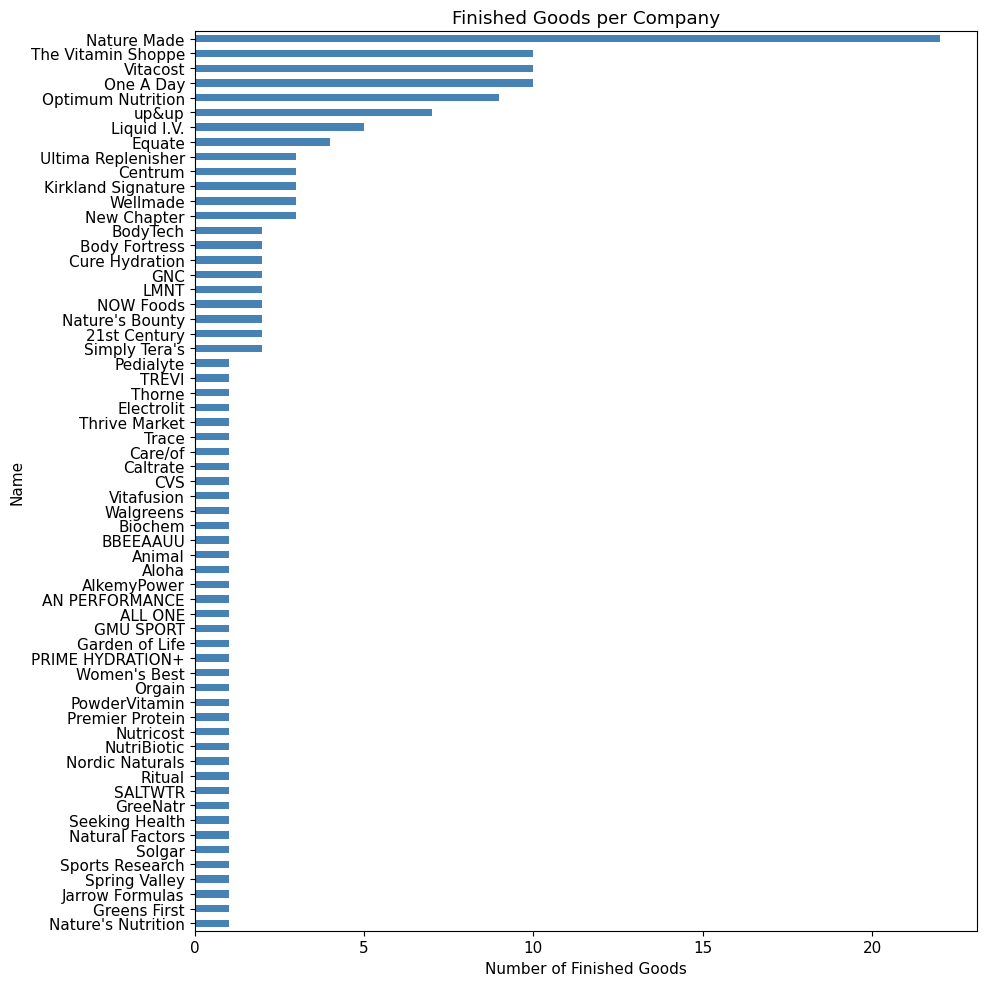

In [4]:
# Products per company (finished goods)
fg_per_company = (
    finished.merge(company, left_on="CompanyId", right_on="Id", suffixes=("_prod", "_co"))
    .groupby("Name").size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 10))
fg_per_company.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Number of Finished Goods")
ax.set_title("Finished Goods per Company")
plt.tight_layout()
plt.show()

## 3. Bill of Materials Structure

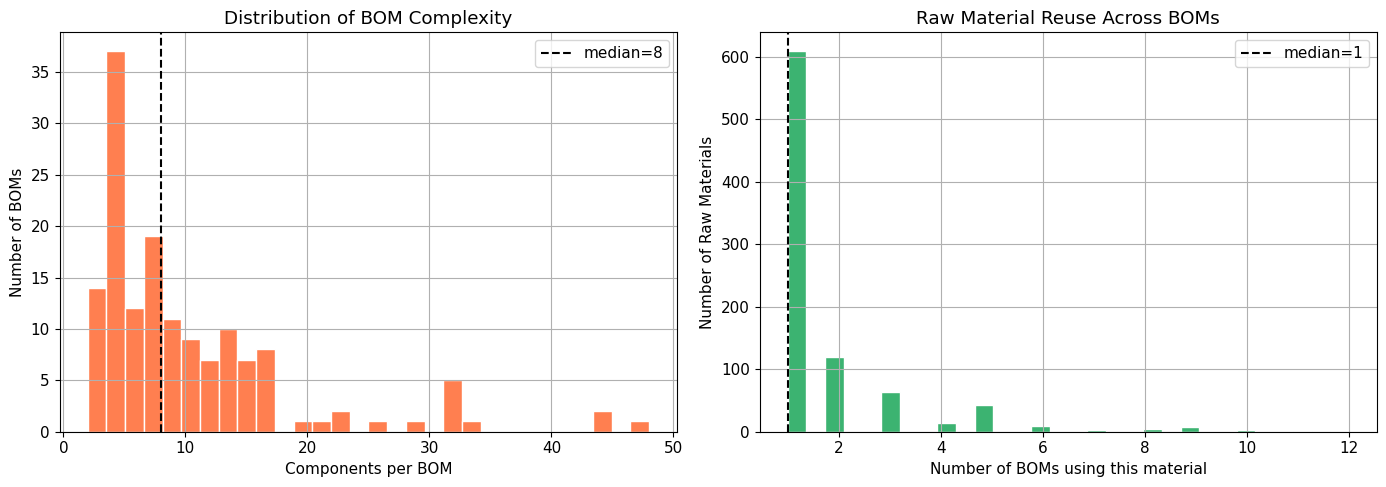


Most reused raw materials (appear in N BOMs):


,SKU,n_boms
376,RM-C30-magnesium-stearate-201fdf47,12
393,RM-C30-vitamin-d3-cholecalciferol-559c9699,11
387,RM-C30-stearic-acid-19acfab5,10
363,RM-C30-cellulose-gel-66b4a4d5,10
507,RM-C38-acesulfame-potassium-f51994fd,9
511,RM-C38-hydrolyzed-whey-protein-9f15d933,9
515,RM-C38-soy-lecithin-563dc5ae,9
517,RM-C38-sunflower-lecithin-57949880,9
518,RM-C38-whey-protein-concentrate-c419722f,9
519,RM-C38-whey-protein-isolate-f910e5ae,9


In [5]:
# How many raw materials per BOM?
components_per_bom = bom_component.groupby("BOMId").size().rename("n_components")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

components_per_bom.hist(bins=30, ax=axes[0], color="coral", edgecolor="white")
axes[0].set_xlabel("Components per BOM")
axes[0].set_ylabel("Number of BOMs")
axes[0].set_title("Distribution of BOM Complexity")
axes[0].axvline(components_per_bom.median(), color="black", ls="--", label=f"median={components_per_bom.median():.0f}")
axes[0].legend()

components_per_bom.describe().to_frame().T.round(1).style.set_caption("Components per BOM stats")

# How many BOMs use each raw material?
boms_per_material = bom_component.groupby("ConsumedProductId").size().rename("n_boms")
boms_per_material.hist(bins=30, ax=axes[1], color="mediumseagreen", edgecolor="white")
axes[1].set_xlabel("Number of BOMs using this material")
axes[1].set_ylabel("Number of Raw Materials")
axes[1].set_title("Raw Material Reuse Across BOMs")
axes[1].axvline(boms_per_material.median(), color="black", ls="--", label=f"median={boms_per_material.median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMost reused raw materials (appear in N BOMs):")
top_reused = (
    boms_per_material.reset_index()
    .merge(product, left_on="ConsumedProductId", right_on="Id")
    .sort_values("n_boms", ascending=False)
    .head(15)[["SKU", "n_boms"]]
)
display(top_reused)

## 4. Supplier Landscape

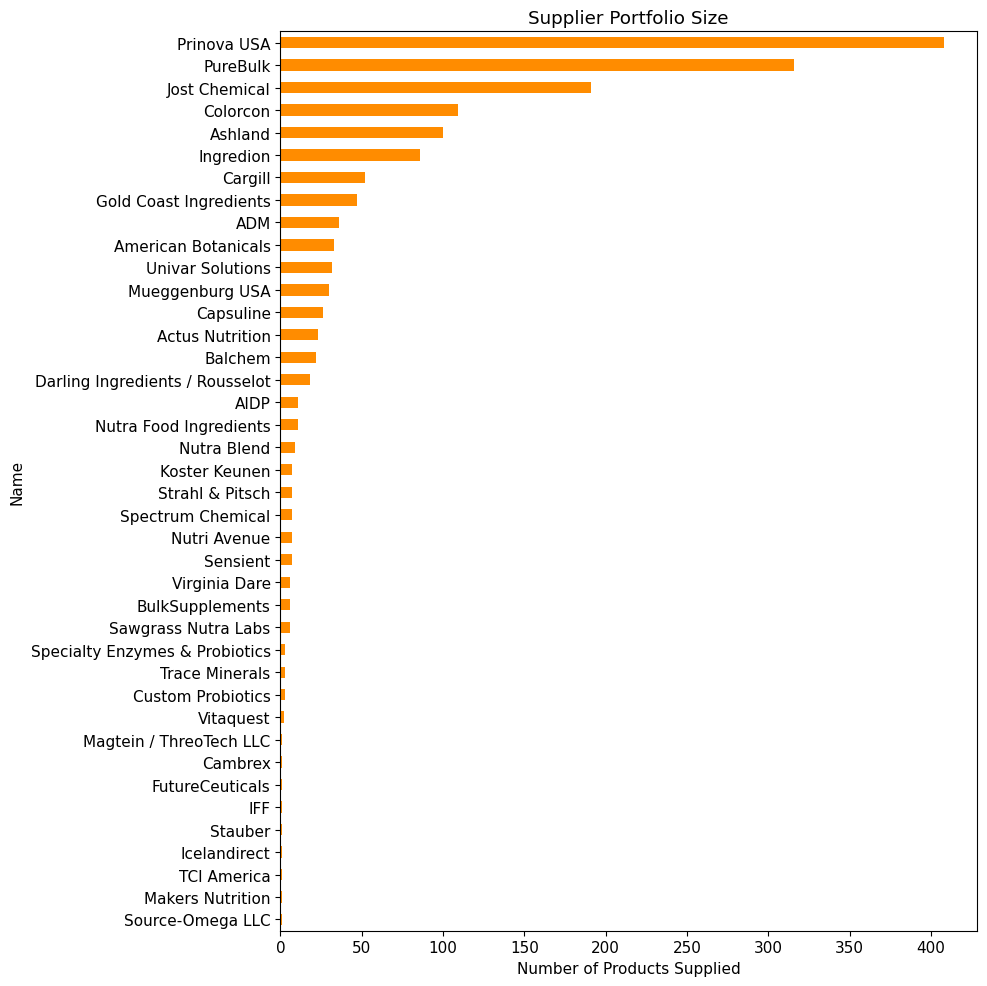

In [6]:
# Products per supplier
products_per_supplier = (
    supplier_product.merge(supplier, left_on="SupplierId", right_on="Id")
    .groupby("Name").size()
    .sort_values(ascending=True)
    .rename("n_products")
)

fig, ax = plt.subplots(figsize=(10, 10))
products_per_supplier.plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Number of Products Supplied")
ax.set_title("Supplier Portfolio Size")
plt.tight_layout()
plt.show()

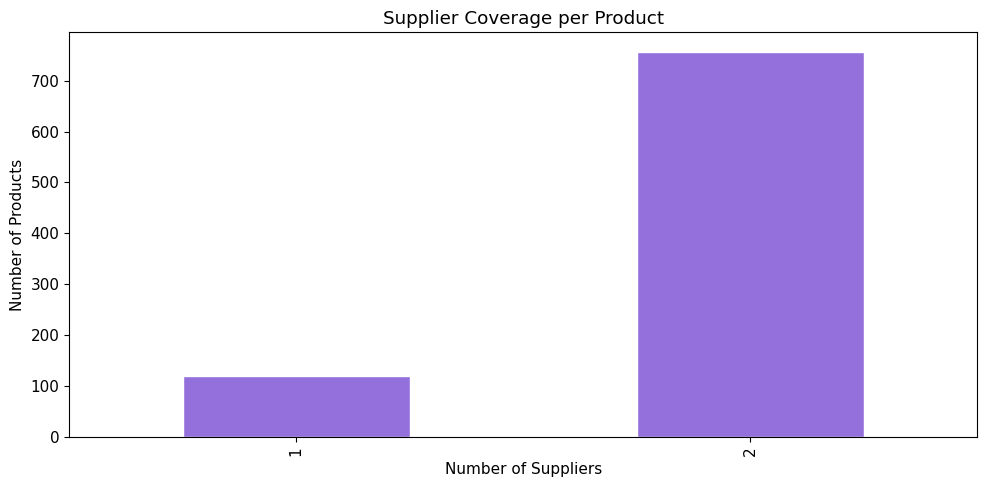

Single-sourced products: 119 / 876 (14%)
Products with 3+ suppliers: 0


In [7]:
# How many suppliers per raw material?
suppliers_per_product = supplier_product.groupby("ProductId").size().rename("n_suppliers")

fig, ax = plt.subplots(figsize=(10, 5))
suppliers_per_product.value_counts().sort_index().plot.bar(ax=ax, color="mediumpurple", edgecolor="white")
ax.set_xlabel("Number of Suppliers")
ax.set_ylabel("Number of Products")
ax.set_title("Supplier Coverage per Product")
plt.tight_layout()
plt.show()

single_source = (suppliers_per_product == 1).sum()
print(f"Single-sourced products: {single_source} / {len(suppliers_per_product)} ({100*single_source/len(suppliers_per_product):.0f}%)")
print(f"Products with 3+ suppliers: {(suppliers_per_product >= 3).sum()}")

## 5. Cross-Company Material Overlap

This is the key to sourcing consolidation: which raw materials appear in BOMs across **multiple companies**?

In [8]:
# Build: for each raw material, which companies use it?
bom_full = (
    bom_component
    .merge(bom, left_on="BOMId", right_on="Id")
    .merge(product.rename(columns={"Id": "FGId", "SKU": "FG_SKU", "CompanyId": "FG_CompanyId", "Type": "FG_Type"}),
           left_on="ProducedProductId", right_on="FGId")
    .merge(product.rename(columns={"Id": "RMId", "SKU": "RM_SKU", "CompanyId": "RM_CompanyId", "Type": "RM_Type"}),
           left_on="ConsumedProductId", right_on="RMId")
    .merge(company.rename(columns={"Id": "CoId", "Name": "CompanyName"}),
           left_on="FG_CompanyId", right_on="CoId")
)

print(f"Full BOM-component join: {len(bom_full)} rows")
bom_full.head(3)

Full BOM-component join: 1528 rows


,BOMId,ConsumedProductId,Id,ProducedProductId,FGId,FG_SKU,FG_CompanyId,FG_Type,RMId,RM_SKU,RM_CompanyId,RM_Type,CoId,CompanyName
0,1,506,1,1,1,FG-iherb-10421,28,finished-good,506,RM-C28-glycerin-85e43afb,28,raw-material,28,NOW Foods
1,1,509,1,1,1,FG-iherb-10421,28,finished-good,509,RM-C28-safflower-oil-a84bc3ce,28,raw-material,28,NOW Foods
2,1,511,1,1,1,FG-iherb-10421,28,finished-good,511,RM-C28-softgel-capsule-bovine-gelatin-5a1a1582,28,raw-material,28,NOW Foods


In [9]:
# Extract the ingredient name from the raw-material SKU pattern: RM-C{id}-{ingredient}-{hash}
def extract_ingredient(sku):
    """Parse ingredient name from SKU like 'RM-C28-glycerin-85e43afb'."""
    parts = sku.split("-")
    if len(parts) >= 4 and parts[0] == "RM":
        return "-".join(parts[2:-1])  # everything between company prefix and hash
    return sku

bom_full["ingredient"] = bom_full["RM_SKU"].apply(extract_ingredient)

# Which ingredients are used by multiple companies?
ingredient_companies = (
    bom_full.groupby("ingredient")["CompanyName"]
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
)
ingredient_companies["n_companies"] = ingredient_companies["CompanyName"].apply(len)
multi_company = ingredient_companies[ingredient_companies.n_companies > 1].sort_values("n_companies", ascending=False)

print(f"Unique ingredients: {len(ingredient_companies)}")
print(f"Used by 2+ companies: {len(multi_company)}")
print(f"Used by 3+ companies: {(multi_company.n_companies >= 3).sum()}")
print(f"\nTop shared ingredients:")
display(multi_company.head(20))

Unique ingredients: 357
Used by 2+ companies: 143
Used by 3+ companies: 92

Top shared ingredients:


,ingredient,CompanyName,n_companies
338,vitamin-d3-cholecalciferol,"[21st Century, GNC, Jarrow Formulas, Kirkland ...",17
163,microcrystalline-cellulose,"[Equate, GNC, Kirkland Signature, Natural Fact...",13
332,vitamin-c,"[BBEEAAUU, Body Fortress, BodyTech, Centrum, E...",13
53,citric-acid,"[AN PERFORMANCE, BodyTech, Electrolit, LMNT, L...",12
140,magnesium,"[AlkemyPower, BBEEAAUU, Centrum, Electrolit, K...",11
351,zinc,"[BBEEAAUU, Body Fortress, Centrum, Kirkland Si...",11
101,gelatin,"[Centrum, Equate, GNC, Kirkland Signature, Nat...",11
347,whey-protein-isolate,"[Animal, Biochem, Body Fortress, GMU SPORT, Ga...",11
152,magnesium-stearate,"[21st Century, Caltrate, Equate, GNC, Natural ...",11
267,silicon-dioxide,"[GNC, Liquid I.V., NOW Foods, Nature Made, One...",10


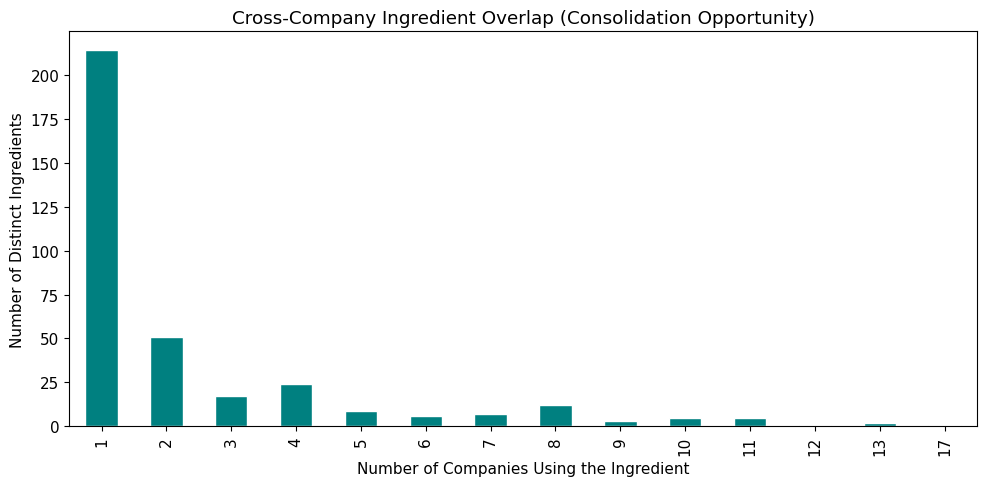

In [10]:
# Distribution of cross-company overlap
fig, ax = plt.subplots(figsize=(10, 5))
ingredient_companies["n_companies"].value_counts().sort_index().plot.bar(
    ax=ax, color="teal", edgecolor="white"
)
ax.set_xlabel("Number of Companies Using the Ingredient")
ax.set_ylabel("Number of Distinct Ingredients")
ax.set_title("Cross-Company Ingredient Overlap (Consolidation Opportunity)")
plt.tight_layout()
plt.show()

## 6. Supplier Concentration & Consolidation Potential

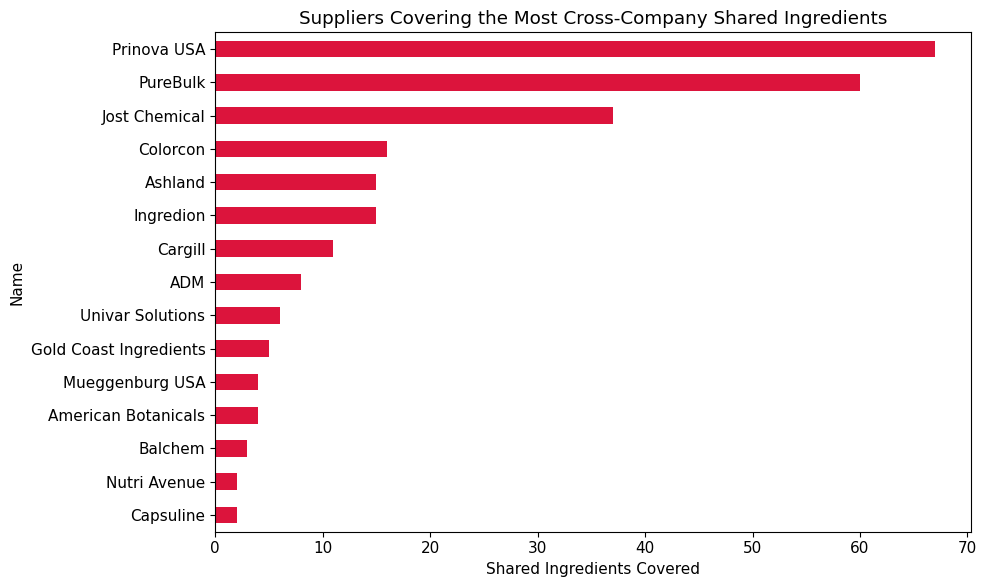

In [11]:
# For shared ingredients, which suppliers currently serve them?
rm_suppliers = (
    supplier_product
    .merge(product, left_on="ProductId", right_on="Id")
    .merge(supplier, left_on="SupplierId", right_on="Id", suffixes=("_prod", "_sup"))
)
rm_suppliers["ingredient"] = rm_suppliers["SKU"].apply(extract_ingredient)

# Supplier overlap matrix: how many ingredients does each pair of suppliers share?
supplier_ingredients = rm_suppliers.groupby("Name")["ingredient"].apply(set)

# Find top suppliers that cover the most shared (multi-company) ingredients
shared_ingredients = set(multi_company["ingredient"])
supplier_shared_coverage = (
    supplier_ingredients.apply(lambda s: len(s & shared_ingredients))
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
supplier_shared_coverage.sort_values().plot.barh(ax=ax, color="crimson")
ax.set_xlabel("Shared Ingredients Covered")
ax.set_title("Suppliers Covering the Most Cross-Company Shared Ingredients")
plt.tight_layout()
plt.show()

## 7. Ingredient Category Analysis

Group raw materials into rough categories based on SKU naming patterns to see what types of materials dominate.

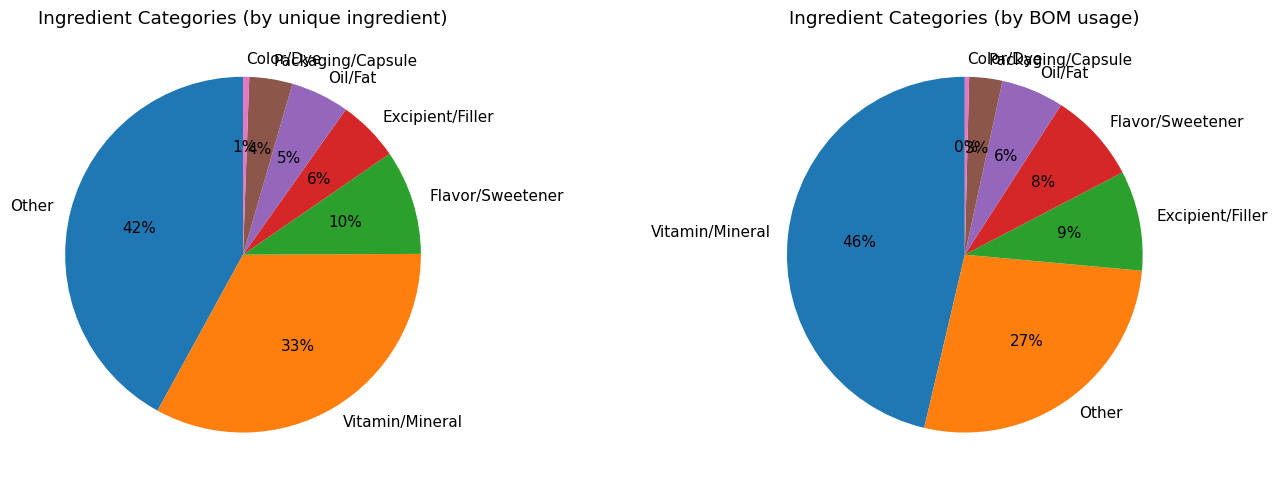

In [12]:
# Categorize ingredients by keywords in their name
CATEGORIES = {
    "Vitamin/Mineral": ["vitamin", "mineral", "calcium", "magnesium", "zinc", "iron",
                        "potassium", "selenium", "manganese", "copper", "chromium",
                        "molybdenum", "iodine", "biotin", "folate", "folic", "niacin",
                        "thiamin", "riboflavin", "pantothenic", "pyridoxine", "cobalamin",
                        "cholecalciferol", "tocopherol", "ascorb", "retinyl"],
    "Packaging/Capsule": ["capsule", "bottle", "cap", "label", "tablet", "coating",
                          "gelatin", "carton", "pouch", "seal", "shrink"],
    "Excipient/Filler": ["cellulose", "stearate", "silica", "starch", "maltodextrin",
                         "dextrin", "croscarmellose", "hydroxypropyl"],
    "Flavor/Sweetener": ["flavor", "sugar", "sweetener", "sucralose", "stevia",
                         "acesulfame", "citric-acid", "malic-acid"],
    "Oil/Fat": ["oil", "fat", "lecithin", "glycerin"],
    "Color/Dye": ["color", "dye", "titanium-dioxide", "caramel"],
}

def categorize(ingredient):
    lower = ingredient.lower()
    for cat, keywords in CATEGORIES.items():
        if any(kw in lower for kw in keywords):
            return cat
    return "Other"

ingredients = pd.DataFrame({"ingredient": bom_full["ingredient"].unique()})
ingredients["category"] = ingredients["ingredient"].apply(categorize)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = ingredients["category"].value_counts()
cat_counts.plot.pie(ax=axes[0], autopct="%1.0f%%", startangle=90)
axes[0].set_ylabel("")
axes[0].set_title("Ingredient Categories (by unique ingredient)")

# Weight by how often they appear in BOMs
bom_cats = bom_full[["ingredient"]].drop_duplicates().merge(ingredients)
bom_full_cats = bom_full.merge(ingredients, on="ingredient")
usage_counts = bom_full_cats["category"].value_counts()
usage_counts.plot.pie(ax=axes[1], autopct="%1.0f%%", startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Ingredient Categories (by BOM usage)")

plt.tight_layout()
plt.show()

## 8. Network View: Company-Supplier Connections

In [13]:
# Which suppliers serve which companies (through their BOMs)?
company_supplier_links = (
    bom_full[["CompanyName", "ConsumedProductId"]].drop_duplicates()
    .merge(supplier_product, left_on="ConsumedProductId", right_on="ProductId")
    .merge(supplier, left_on="SupplierId", right_on="Id")
    .groupby(["CompanyName", "Name"]).size()
    .reset_index(name="n_materials")
    .rename(columns={"Name": "SupplierName"})
)

# Companies per supplier
companies_per_supplier = (
    company_supplier_links.groupby("SupplierName")["CompanyName"]
    .apply(list).reset_index()
)
companies_per_supplier["n_companies"] = companies_per_supplier["CompanyName"].apply(len)
companies_per_supplier = companies_per_supplier.sort_values("n_companies", ascending=False)

print("Suppliers serving multiple companies (consolidation bridges):")
display(companies_per_supplier[companies_per_supplier.n_companies > 1].head(15))

Suppliers serving multiple companies (consolidation bridges):


,SupplierName,CompanyName,n_companies
26,Prinova USA,"[21st Century, ALL ONE, AN PERFORMANCE, Alkemy...",60
27,PureBulk,"[21st Century, ALL ONE, Animal, BBEEAAUU, Body...",52
18,Jost Chemical,"[21st Century, ALL ONE, AN PERFORMANCE, Alkemy...",44
17,Ingredion,"[ALL ONE, AN PERFORMANCE, Aloha, Animal, Bioch...",36
9,Cargill,"[ALL ONE, Aloha, Animal, Biochem, Body Fortres...",32
14,Gold Coast Ingredients,"[AN PERFORMANCE, Aloha, Animal, BBEEAAUU, Bioc...",31
10,Colorcon,"[21st Century, ALL ONE, CVS, Caltrate, Equate,...",27
0,ADM,"[ALL ONE, Aloha, Animal, Biochem, Body Fortres...",25
4,Ashland,"[21st Century, ALL ONE, CVS, Caltrate, Equate,...",25
37,Univar Solutions,"[21st Century, AN PERFORMANCE, Animal, BBEEAAU...",24


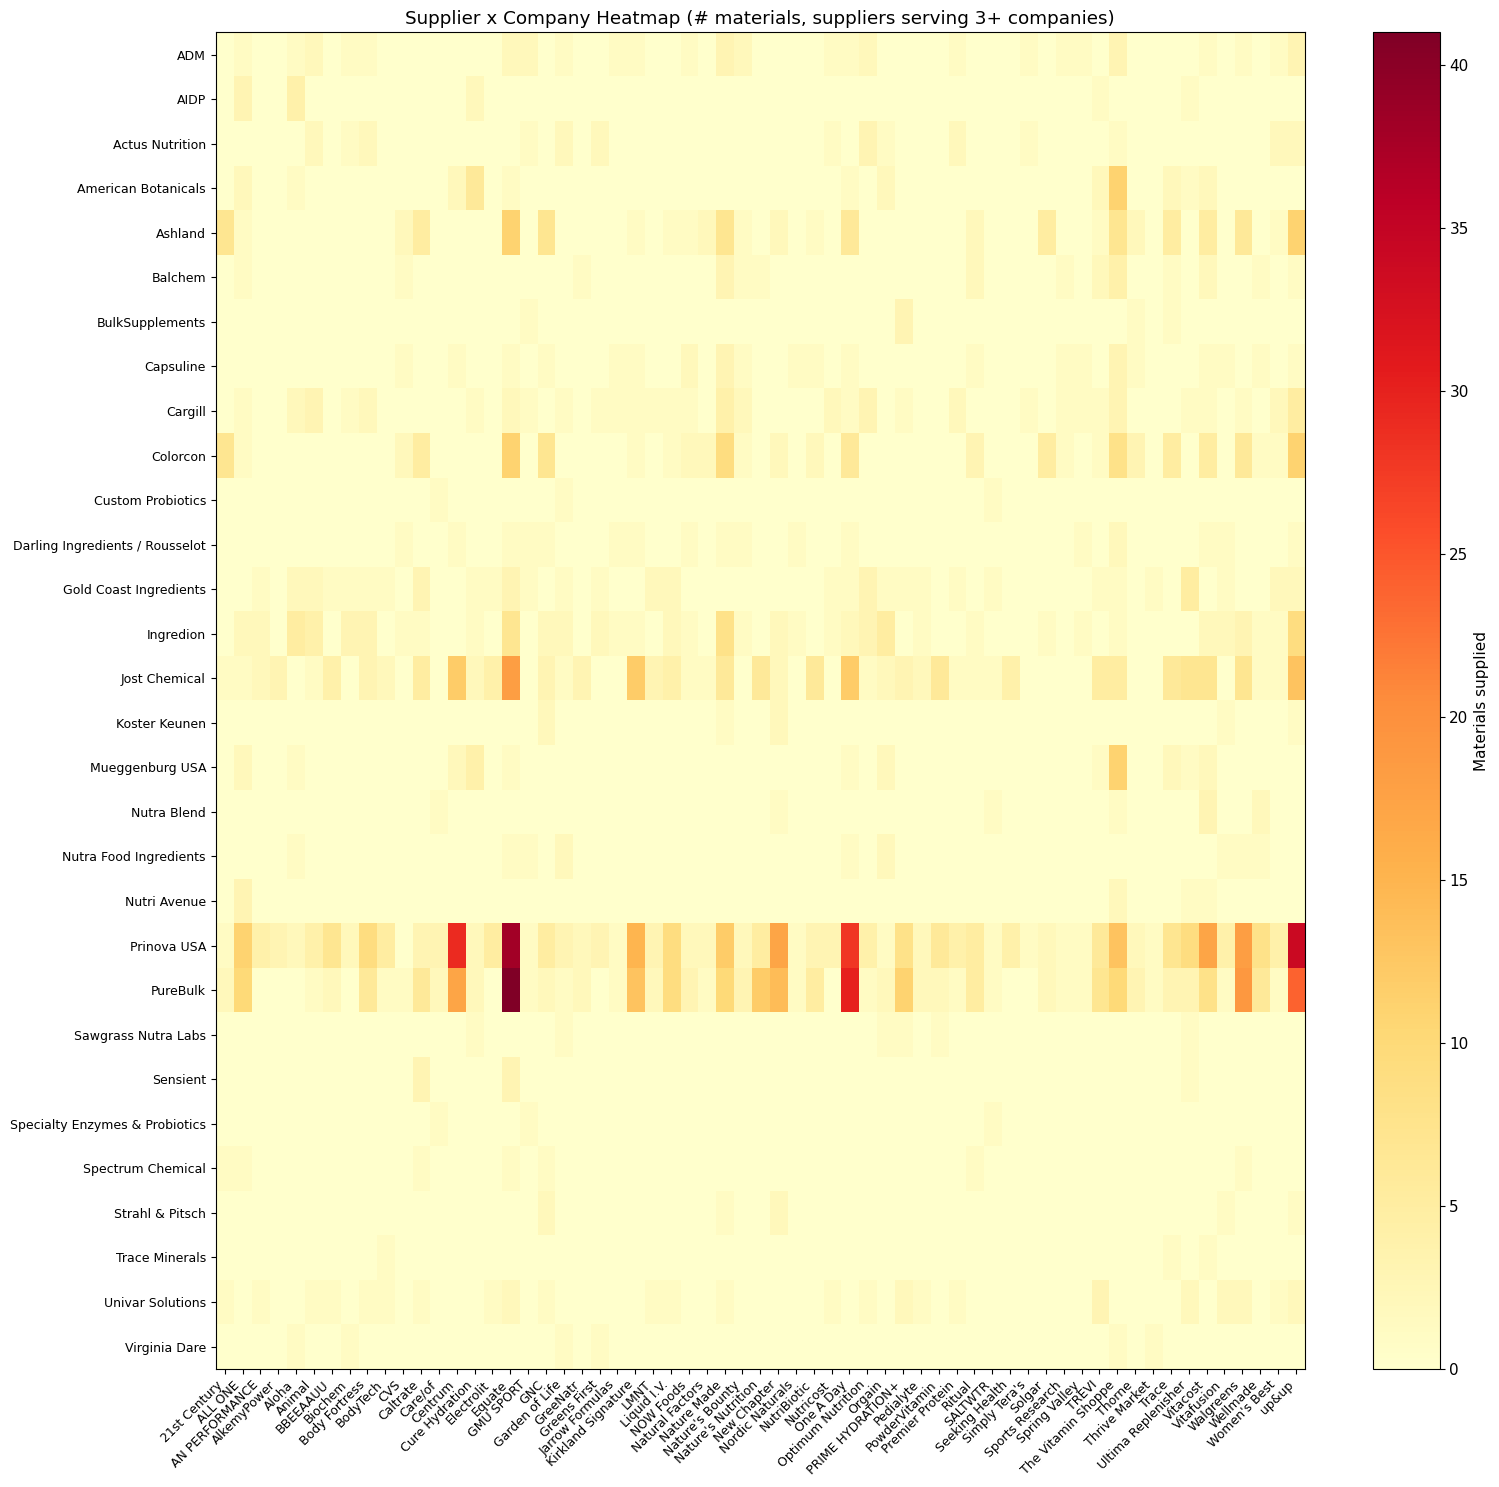

In [14]:
# Heatmap: supplier x company (materials supplied)
pivot = company_supplier_links.pivot_table(
    index="SupplierName", columns="CompanyName", values="n_materials", fill_value=0
)
# Keep only suppliers that serve 3+ companies for readability
multi_co_suppliers = companies_per_supplier[companies_per_supplier.n_companies >= 3]["SupplierName"]
pivot_filtered = pivot.loc[pivot.index.isin(multi_co_suppliers)]

if len(pivot_filtered) > 0:
    fig, ax = plt.subplots(figsize=(16, max(6, len(pivot_filtered) * 0.5)))
    im = ax.imshow(pivot_filtered.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(pivot_filtered.columns)))
    ax.set_xticklabels(pivot_filtered.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(pivot_filtered.index)))
    ax.set_yticklabels(pivot_filtered.index, fontsize=9)
    ax.set_title("Supplier x Company Heatmap (# materials, suppliers serving 3+ companies)")
    plt.colorbar(im, ax=ax, label="Materials supplied")
    plt.tight_layout()
    plt.show()
else:
    print("No suppliers serve 3+ companies — try lowering the threshold.")

## 9. Key Findings Summary

In [15]:
orphaned_rm = set(raw["Id"]) - set(bom_component["ConsumedProductId"])
unsupplied_rm = set(raw["Id"]) - set(supplier_product["ProductId"])
rm_in_bom = set(bom_component["ConsumedProductId"])
unsupplied_in_bom = rm_in_bom - set(supplier_product["ProductId"])

print("=" * 60)
print("DATA SUMMARY")
print("=" * 60)
print(f"Companies:                       {len(company):>5}")
print(f"Finished goods (with BOMs):      {len(finished):>5}")
print(f"Raw materials:                   {len(raw):>5}")
print(f"Suppliers:                       {len(supplier):>5}")
print(f"")
print(f"Avg components per BOM:          {len(bom_component)/len(bom):>5.1f}")
print(f"Ingredients shared across 2+ co: {len(multi_company):>5}")
print(f"Single-sourced products:         {single_source:>5}")
print(f"Raw materials not in any BOM:    {len(orphaned_rm):>5}")
print(f"BOM materials with no supplier:  {len(unsupplied_in_bom):>5}")
print(f"")
print("KEY OPPORTUNITIES:")
print(f"  - {len(multi_company)} ingredients used across multiple companies")
print(f"    => consolidation candidates")
print(f"  - {single_source} products with only 1 supplier")
print(f"    => supply risk / no competitive pricing")
print(f"  - {len(unsupplied_in_bom)} BOM materials have no supplier mapped")
print(f"    => data gaps to resolve")

DATA SUMMARY
Companies:                          61
Finished goods (with BOMs):        149
Raw materials:                     876
Suppliers:                          40

Avg components per BOM:           10.3
Ingredients shared across 2+ co:   143
Single-sourced products:           119
Raw materials not in any BOM:        0
BOM materials with no supplier:      0

KEY OPPORTUNITIES:
  - 143 ingredients used across multiple companies
    => consolidation candidates
  - 119 products with only 1 supplier
    => supply risk / no competitive pricing
  - 0 BOM materials have no supplier mapped
    => data gaps to resolve


In [16]:
conn.close()